In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# qrafikin gorunusu ucun
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [2]:
df = pd.read_csv("NYC.csv")

In [3]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
df.shape

(1458644, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [6]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

In [7]:
df["pickup_datetime"].dtype

dtype('<M8[us]')

In [8]:
df["trip_duration_min"] = df["trip_duration"] / 60

In [10]:
df["trip_duration_min"].describe()

count    1.458644e+06
mean     1.599154e+01
std      8.729053e+01
min      1.666667e-02
25%      6.616667e+00
50%      1.103333e+01
75%      1.791667e+01
max      5.877137e+04
Name: trip_duration_min, dtype: float64

In [11]:
df = df[(df["trip_duration_min"] >= 1) & (df["trip_duration_min"] <= 120)]

In [12]:
df["trip_duration_min"].describe()

count    1.447796e+06
mean     1.401459e+01
std      1.088770e+01
min      1.000000e+00
25%      6.683333e+00
50%      1.108333e+01
75%      1.793333e+01
max      1.198500e+02
Name: trip_duration_min, dtype: float64

In [13]:
df["hour"] = df["pickup_datetime"].dt.hour
df["weekday"] = df["pickup_datetime"].dt.day_name()
df["month"] = df["pickup_datetime"].dt.month_name()

In [14]:
df[["pickup_datetime","hour","weekday","month"]].head()

,pickup_datetime,hour,weekday,month
0,2016-03-14 17:24:55,17,Monday,March
1,2016-06-12 00:43:35,0,Sunday,June
2,2016-01-19 11:35:24,11,Tuesday,January
3,2016-04-06 19:32:31,19,Wednesday,April
4,2016-03-26 13:30:55,13,Saturday,March


<Axes: xlabel='hour'>

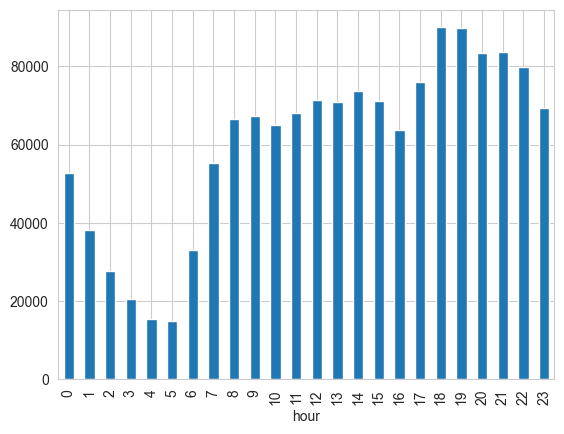

In [ ]:
hourly_trips = df.groupby("hour")["id"].count()
hourly_trips.plot(kind="bar") 

In [16]:
hourly_trips.idxmax(), hourly_trips.max()

(np.int32(18), np.int64(90022))

In [17]:
hourly_trips.idxmin(), hourly_trips.min()

(np.int32(5), np.int64(14767))

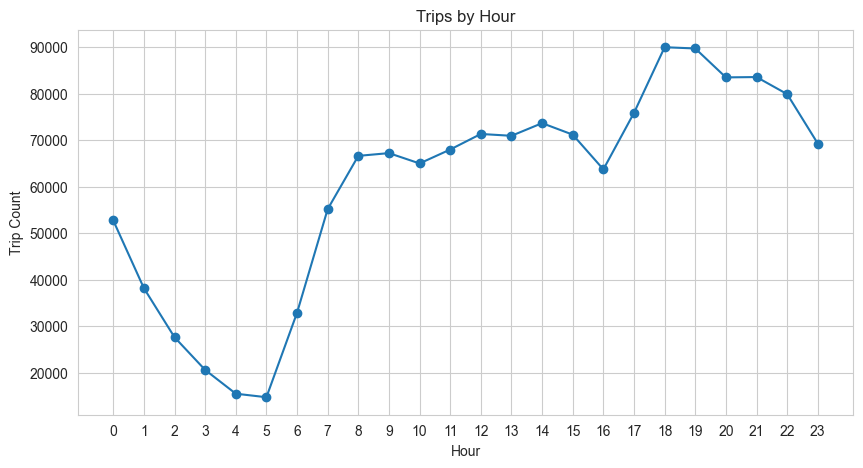

In [22]:
plt.figure(figsize=(10,5))
plt.plot(hourly_trips.index, hourly_trips.values, marker="o")
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Trip Count")
plt.xticks(range(24))
plt.show()

In [23]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_trips = (df.groupby("weekday")["id"].count().reindex(weekday_order))
weekday_trips

weekday
Monday       186051
Tuesday      201318
Wednesday    208751
Thursday     216947
Friday       221870
Saturday     219190
Sunday       193669
Name: id, dtype: int64

In [24]:
weekday_trips.idxmax(), weekday_trips.max()

('Friday', np.int64(221870))

In [25]:
weekday_trips.idxmin(), weekday_trips.min()

('Monday', np.int64(186051))

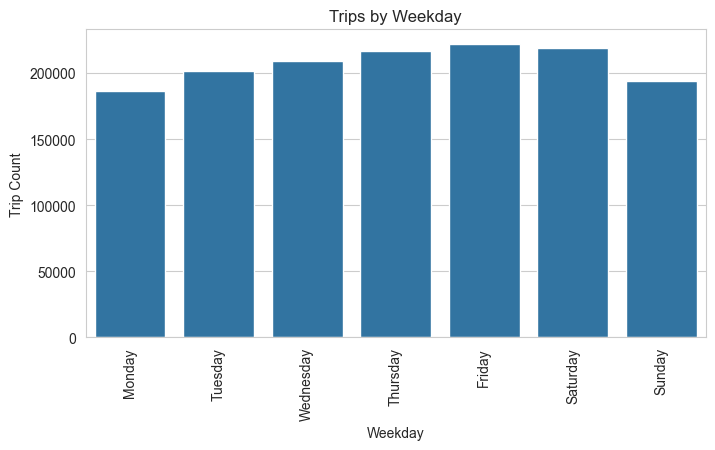

In [27]:
plt.figure(figsize=(8,4))
sns.barplot(x=weekday_trips.index,y=weekday_trips.values)
plt.title("Trips by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Trip Count")
plt.xticks(rotation=90)
plt.show()

In [ ]:
hourly_avg_duration = df.groupby("hour")["trip_duration_min"].mean()
hourly_avg_duration #plot(kind="bar") elave ederek vizual gore bilerik

hour
0     13.099148
1     12.406891
2     11.788360
3     11.809817
4     12.380970
5     12.006863
6     11.266490
7     12.703321
8     13.963393
9     14.120025
10    14.189638
11    14.659226
12    14.696227
13    15.010536
14    15.856380
15    16.164062
16    16.158841
17    15.595790
18    14.398233
19    13.222705
20    12.864063
21    12.999611
22    13.472555
23    13.607323
Name: trip_duration_min, dtype: float64

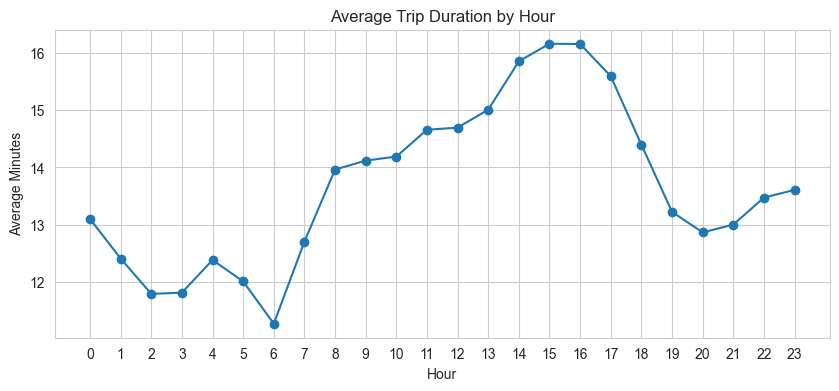

In [33]:
plt.figure(figsize=(10,4))
plt.plot(hourly_avg_duration.index,hourly_avg_duration.values,marker="o")
plt.title("Average Trip Duration by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Minutes")
plt.xticks(range(24))
plt.show()

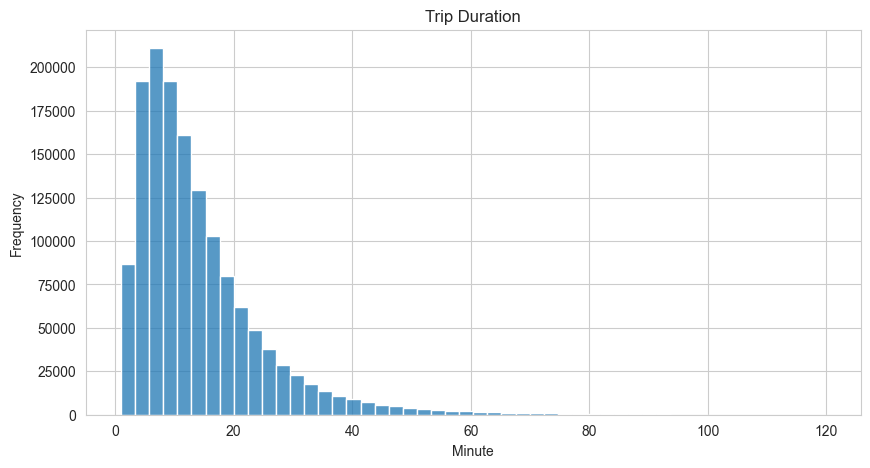

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(df["trip_duration_min"],bins=50)
plt.title("Trip Duration")
plt.xlabel("Minute")
plt.ylabel("Frequency")
plt.show()

In [37]:
month_order = ["January","February","March","April","May","June"]
monthly_trips = (df.groupby("month")["id"].count().reindex(month_order))

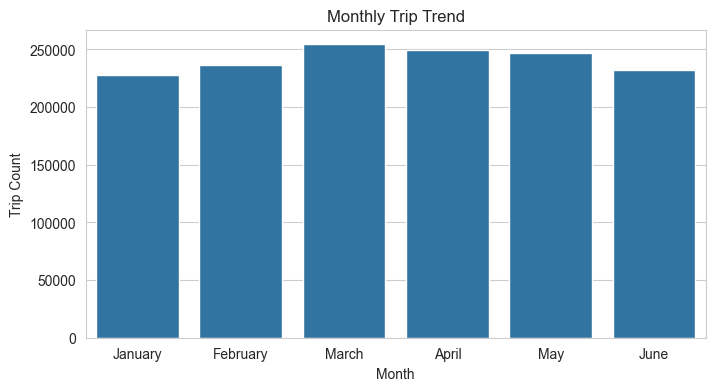

In [39]:
plt.figure(figsize=(8,4))
sns.barplot(x=monthly_trips.index,y=monthly_trips.values)
plt.title("Monthly Trip Trend")
plt.xlabel("Month")
plt.ylabel("Trip Count")
plt.show()

In [40]:
mean_duration = df["trip_duration_min"].mean()
median_duration = df["trip_duration_min"].median()
print("Mean:", mean_duration)
print("Median:", median_duration)

Mean: 14.014593630594366
Median: 11.083333333333334


In [41]:
vendor_share = df["vendor_id"].value_counts(normalize=True) * 100
vendor_share

vendor_id
2    53.504223
1    46.495777
Name: proportion, dtype: float64

In [42]:
heatmap_data = df.pivot_table(values="id",index="hour",columns="weekday",aggfunc="count")
heatmap_data = heatmap_data[weekday_order]

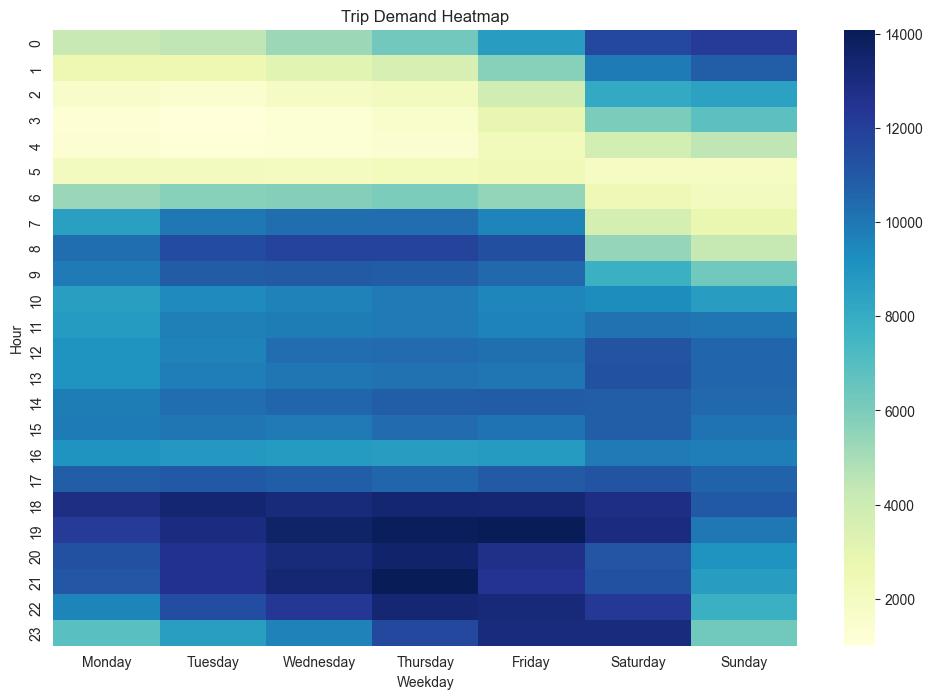

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Trip Demand Heatmap")
plt.xlabel("Weekday")
plt.ylabel("Hour")
plt.show() #bonus

In [44]:
vendor_avg = df.groupby("vendor_id")["trip_duration_min"].mean()
vendor_avg

vendor_id
1    13.933970
2    14.084657
Name: trip_duration_min, dtype: float64

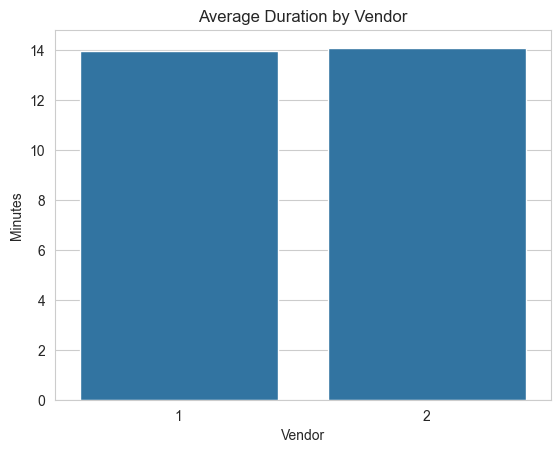

In [ ]:
sns.barplot(x=vendor_avg.index, y=vendor_avg.values)
plt.title("Average Duration by Vendor")
plt.xlabel("Vendor")
plt.ylabel("Minutes")
plt.show()#bonus